# Ejercicio 3

En este ejercicio se estudia numéricamente la **distribución de Marchenko–Pastur** y su relación con matrices aleatorias de Wishart. Primero, se analiza cómo cambia la forma de la distribución para distintos valores del parámetro $\kappa=T/N$, observando la variación de sus bordes espectrales y la concentración de los autovalores. Posteriormente, se construye un **Wishart Orthogonal Ensemble (WOE)** mediante matrices gaussianas aleatorias de tamaño $N=200$ y $T=500$. Se calculan los valores propios de 100 realizaciones y se agrupan en un histograma normalizado. Finalmente, la distribución numérica obtenida se compara con la predicción teórica de Marchenko–Pastur y con sus correspondientes límites espectrales.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Inciso a)
Este código grafica la **distribución de Marchenko–Pastur** para distintos valores del parámetro

$$
\kappa = \frac{T}{N}.
$$

Para cada $\kappa$, se calculan los límites espectrales

$$
\lambda_{\pm}
=
\sigma^2
\left(
\frac{1}{\sqrt{\kappa}}
\pm 1
\right)^2,
$$

que determinan el intervalo donde la densidad es distinta de cero.

Después se evalúa la función

$$
\rho(\lambda)
=
\frac{\kappa}
{2\pi\sigma^2\lambda}
\sqrt{
(\lambda_{+}-\lambda)
(\lambda-\lambda_{-})
}.
$$

Al comparar las curvas se observa cómo cambia la forma y el ancho de la distribución cuando varía $\kappa$.

En particular, al aumentar $\kappa$, el espectro se concentra cada vez más alrededor de $\lambda = 1$.

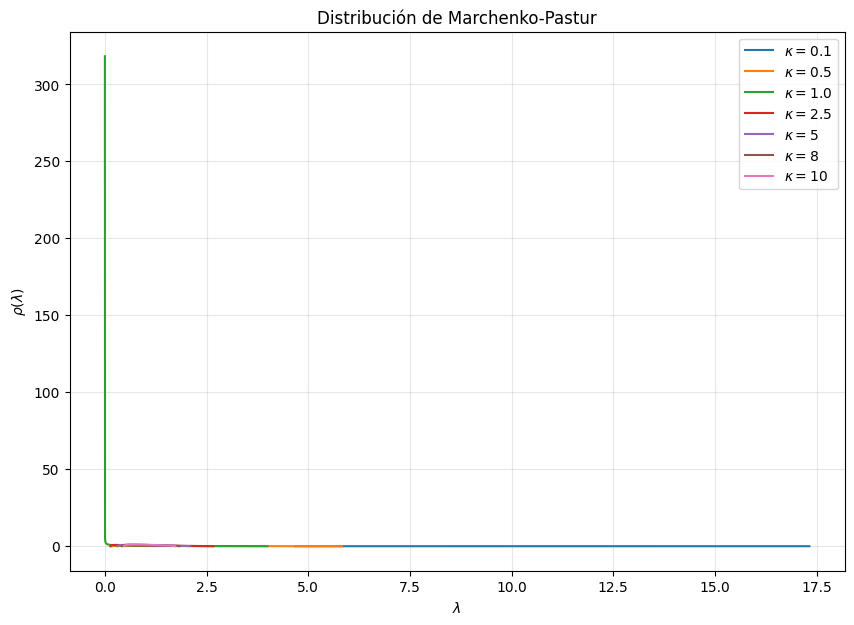

In [7]:
kappas = [0.1, 0.5, 1.0, 2.5, 5, 8, 10]

sigma2 = 1.0

plt.figure(figsize=(10, 7))

for kappa in kappas:

    lambda_minus = sigma2 * (1 / np.sqrt(kappa) - 1)**2
    lambda_plus  = sigma2 * (1 / np.sqrt(kappa) + 1)**2

    # Evitamos exactamente lambda = 0 cuando kappa = 1
    epsilon = 1e-6

    if lambda_minus == 0:
        lam = np.linspace(epsilon, lambda_plus, 1000)
    else:
        lam = np.linspace(lambda_minus, lambda_plus, 1000)

    rho = (kappa/ (2 * np.pi * sigma2 * lam) * np.sqrt((lambda_plus - lam) * (lam - lambda_minus)))

    plt.plot(lam, rho, label=fr"$\kappa={kappa}$")

plt.xlabel(r"$\lambda$")
plt.ylabel(r"$\rho(\lambda)$")
plt.title("Distribución de Marchenko-Pastur")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Inciso b)

Este código genera un **Wishart Orthogonal Ensemble (WOE)** compuesto por 100 realizaciones. En cada realización se construye una matriz aleatoria $A$ de dimensiones $N=200$ y $T=500$, cuyas entradas son variables aleatorias gaussianas independientes con media cero y varianza unitaria.

A partir de cada matriz $A$ se construye la matriz de Wishart

$$
C=\frac{AA^T}{T},
$$

y posteriormente se calculan sus valores propios.

Los autovalores obtenidos de todas las realizaciones se agrupan en un histograma normalizado, el cual se compara con la **distribución teórica de Marchenko–Pastur**. Para estos parámetros, la razón dimensional está dada por

$$
\kappa=\frac{T}{N}=\frac{500}{200}=2.5.
$$

Asimismo, se calculan los bordes espectrales $\lambda_{-}$ y $\lambda_{+}$, que delimitan el intervalo en el cual se espera encontrar la mayor parte del espectro en el límite de matrices grandes.

El objetivo de la simulación es verificar numéricamente que la distribución empírica de los valores propios del WOE converge hacia la distribución de Marchenko–Pastur.


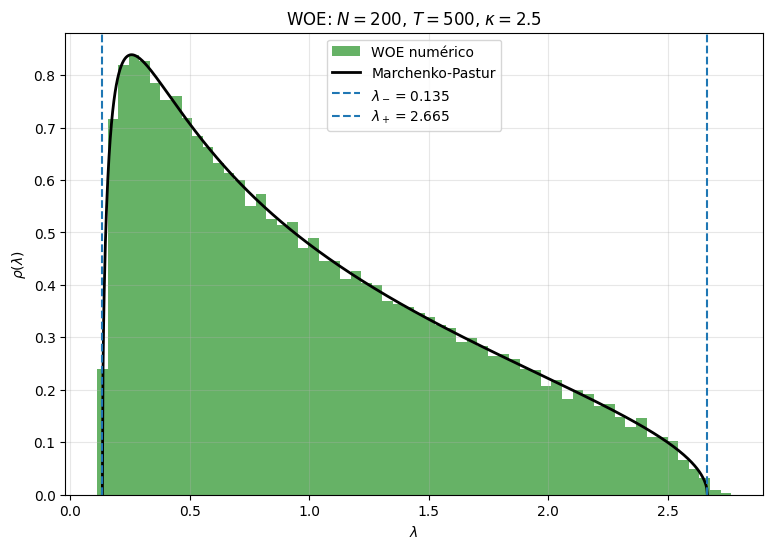

In [12]:

N = 200
T = 500
miembros = 100

def matriz_wishart(N, T):
    A = np.random.normal(0, 1, size=(N, T))
    C = (A @ A.T) / T
    return C


autovalores_WOE = []

for i in range(miembros):
    C = matriz_wishart(N, T)
    autovalores = np.linalg.eigvalsh(C)
    autovalores_WOE.extend(autovalores)

autovalores_WOE = np.array(autovalores_WOE)

# Parámetro de Marchenko-Pastur
kappa = T / N
sigma2 = 1.0

# Bordes espectrales
lambda_minus = sigma2 * (1 / np.sqrt(kappa) - 1)**2
lambda_plus  = sigma2 * (1 / np.sqrt(kappa) + 1)**2

# Curva teórica
lam = np.linspace(lambda_minus, lambda_plus, 1000)

rho = (kappa/ (2 * np.pi * sigma2 * lam) * np.sqrt((lambda_plus - lam) * (lam - lambda_minus)))

# Gráfica
plt.figure(figsize=(9, 6))

plt.hist(autovalores_WOE,bins=60,density=True,alpha=0.6,label="WOE numérico", color = "green")

plt.plot(lam,rho,linewidth=2,label="Marchenko-Pastur", color= "black")

plt.axvline(lambda_minus,linestyle="--",label=fr"$\lambda_-={lambda_minus:.3f}$")

plt.axvline(lambda_plus,linestyle="--",label=fr"$\lambda_+={lambda_plus:.3f}$")

plt.xlabel(r"$\lambda$")
plt.ylabel(r"$\rho(\lambda)$")

plt.title(fr"WOE: $N={N}$, $T={T}$, "fr"$\kappa={kappa:.1f}$")

plt.legend()
plt.grid(alpha=0.3)

plt.show()